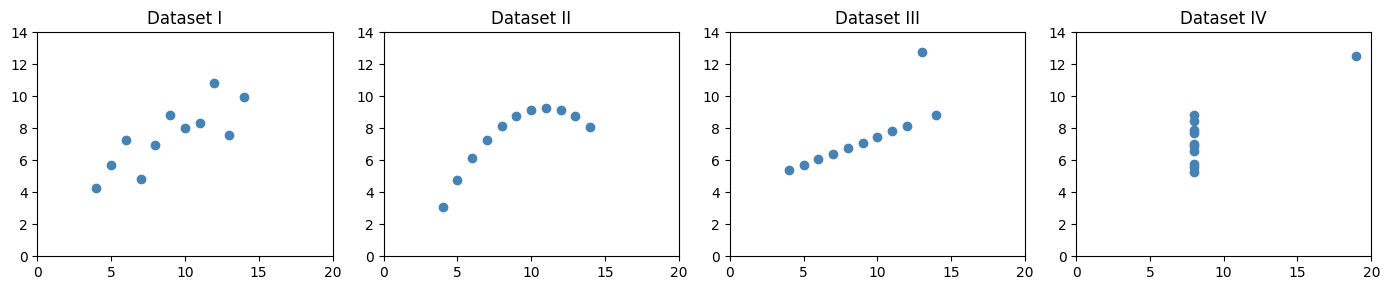

In [1]:
import matplotlib.pyplot as plt

datasets = {
    'I':   {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    'II':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},
    'III': {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    'IV':  {'x': [8,8,8,8,8,8,8,19,8,8,8],
             'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))   # fig = 도화지, axes = 4개 그림 영역

for ax, (name, d) in zip(axes, datasets.items()):
    ax.scatter(d['x'], d['y'], color='steelblue')
    ax.set_title(f'Dataset {name}')
    ax.set_xlim(0, 20); ax.set_ylim(0, 14)

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    # Windows 내장
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      # macOS
else:
    plt.rc('font', family='NanumGothic')      # Ubuntu: sudo apt install fonts-nanum

plt.rc('axes', unicode_minus=False)           # 마이너스 기호 깨짐 방지

In [4]:
import pandas as pd

TITANIC_URL = (
  'https://raw.githubusercontent.com/'
  'datasciencedojo/datasets/master/titanic.csv'
)
titanic = pd.read_csv(TITANIC_URL)
titanic.shape   # (891, 12)

(891, 12)

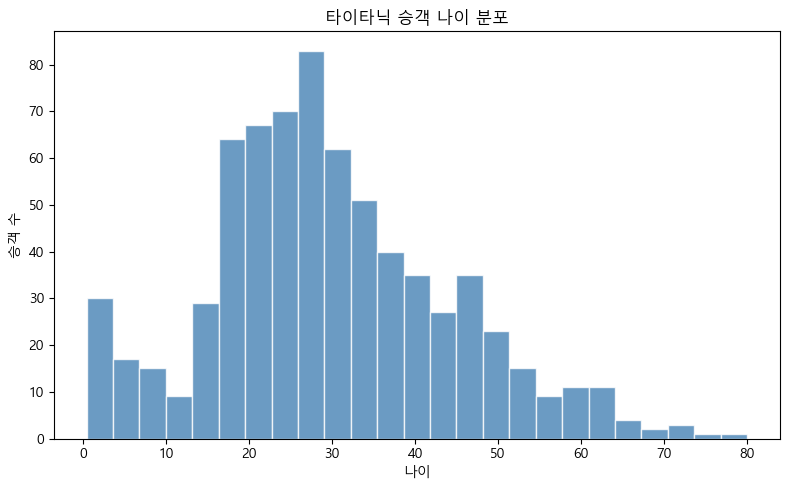

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(titanic['Age'].dropna(),
        bins=25,
        color='steelblue',
        edgecolor='white',
        alpha=0.8)
ax.set_xlabel('나이')
ax.set_ylabel('승객 수')
ax.set_title('타이타닉 승객 나이 분포')
plt.tight_layout()
plt.show()

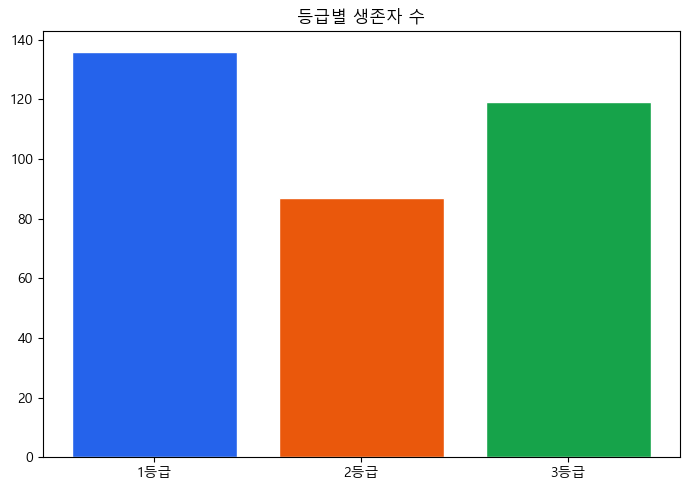

In [7]:
surv_class = titanic.groupby('Pclass')['Survived'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(surv_class.index, surv_class.values,
       color=['#2563eb','#ea580c','#16a34a'],
       edgecolor='white')
ax.set_title('등급별 생존자 수')
ax.set_xticks([1,2,3])
ax.set_xticklabels(['1등급','2등급','3등급'])
plt.tight_layout(); plt.show()

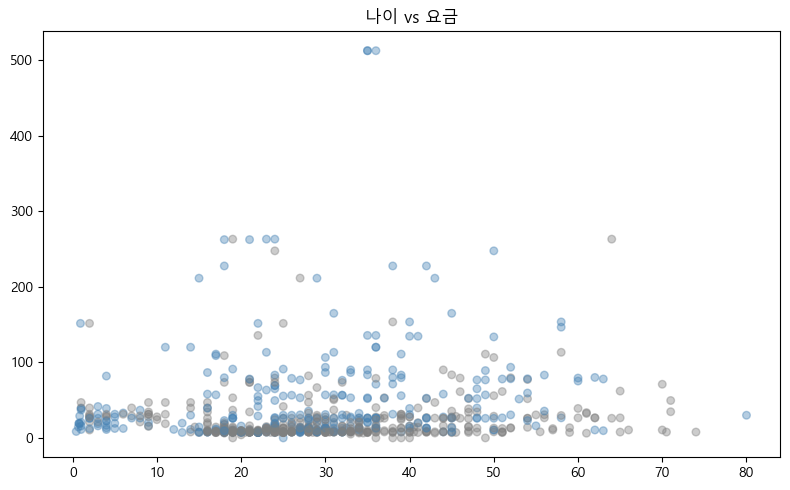

In [10]:
colors = titanic['Survived'].map(
    {0: 'gray', 1: 'steelblue'})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(titanic['Age'],
           titanic['Fare'],
           c=colors, alpha=0.4, s=30)
ax.set_title('나이 vs 요금')
plt.tight_layout(); plt.show()

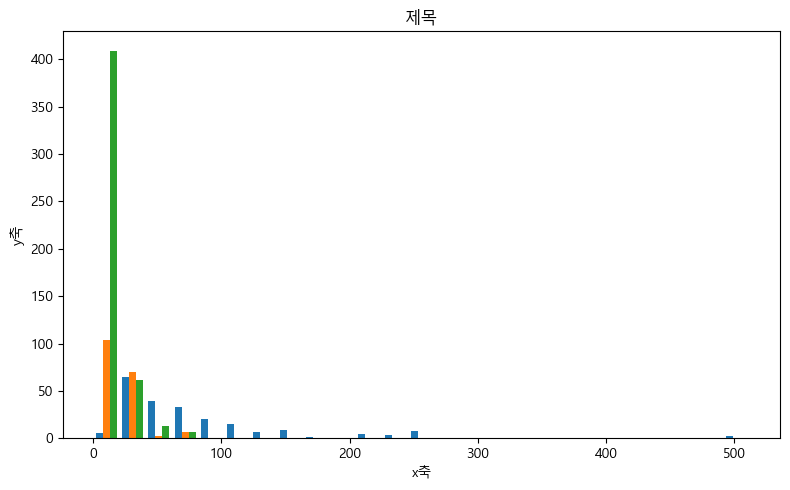

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
#  fig = 도화지 전체
#  ax  = 그림이 그려지는 영역

ax.hist(data, bins=25)
ax.set_title('제목')
ax.set_xlabel('x축')
ax.set_ylabel('y축')
plt.tight_layout()
plt.show()

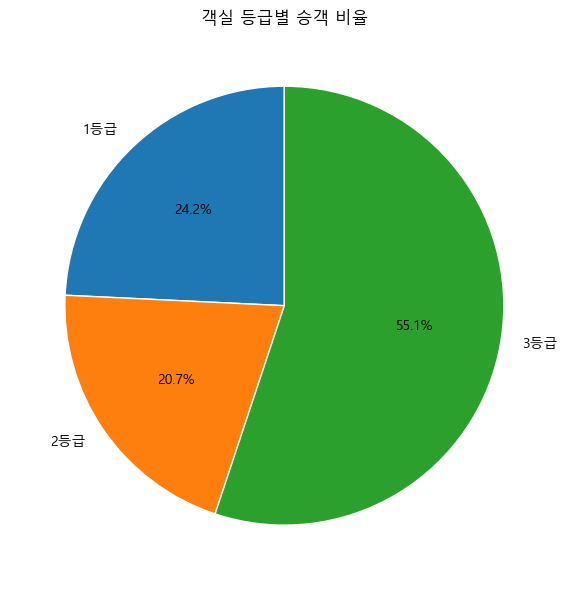

In [12]:
class_counts = titanic['Pclass'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(class_counts.values,
       labels=['1등급','2등급','3등급'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('객실 등급별 승객 비율')
plt.tight_layout(); plt.show()

In [16]:
imdb = pd.read_csv('./imdb_top_1000.csv')
imdb.shape    # (1000, 16)
imdb.info()
imdb.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [17]:
imdb['Genre'].head(3).tolist()

['Drama', 'Crime, Drama', 'Action, Crime, Drama']

In [18]:
imdb['Released_Year'] = pd.to_numeric(
    imdb['Released_Year'], errors='coerce'
)

In [19]:
imdb['Gross'].head(3)
# ['28,341,469', '134,966,411', ...]

imdb['Gross_clean'] = (
    imdb['Gross']
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [30]:
import plotly.express as px

fig = px.histogram(
    imdb,
    x='IMDB_Rating',
    nbins=20,
    marginal='box',      # 박스플롯 동시에!
    title='IMDB 평점 분포',
    template='simple_white'
)
fig.show()

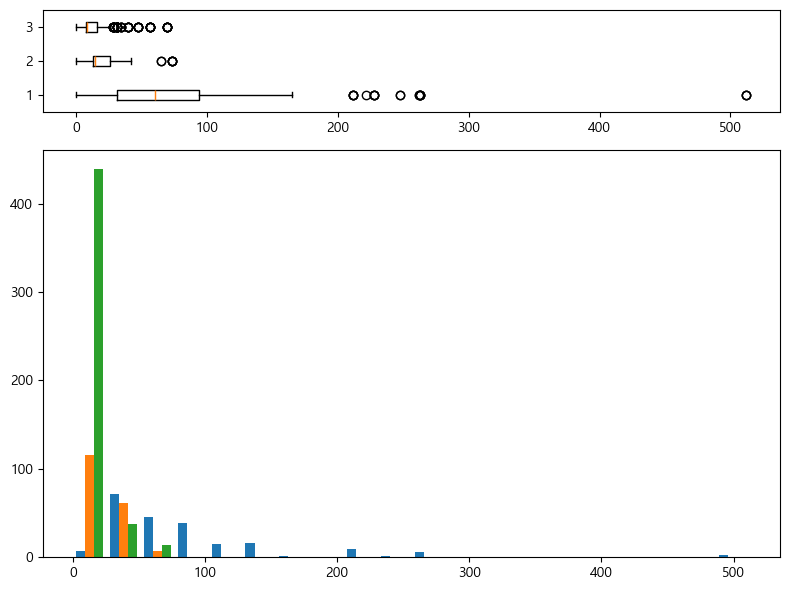

In [23]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 6),
    gridspec_kw={'height_ratios': [1, 4]}
)
ax1.boxplot(data, vert=False)
ax2.hist(data, bins=20)
plt.tight_layout()

In [24]:
fig = px.scatter(
    imdb,
    x='No_of_Votes',
    y='IMDB_Rating',
    hover_name='Series_Title',      # 굵게 표시
    hover_data=['Released_Year',
                'Genre'],
    title='투표 수 vs IMDB 평점',
    template='simple_white',
    opacity=0.6
)
fig.show()
fig.write_html('imdb_scatter.html')

In [25]:
imdb['Released_Year'].value_counts().tail(10)

Released_Year
1932.0    2
1936.0    1
1921.0    1
1924.0    1
1937.0    1
1926.0    1
1920.0    1
1930.0    1
1922.0    1
1943.0    1
Name: count, dtype: int64

In [27]:
imdb['Gross'].head(3)

0     28,341,469
1    134,966,411
2    534,858,444
Name: Gross, dtype: str

In [28]:
imdb['Genre'].head(3).tolist()

['Drama', 'Crime, Drama', 'Action, Crime, Drama']

In [36]:
df = imdb.dropna(subset=['Released_Year']).copy()

df['Released_Year'] = df['Released_Year'].astype(int)

year_counts = df['Released_Year'].value_counts().sort_index()

In [37]:
year_counts.tail(10)

Released_Year
2011    18
2012    24
2013    28
2014    32
2015    25
2016    28
2017    22
2018    19
2019    23
2020     6
Name: count, dtype: int64

In [38]:
px.bar(
    x=year_counts.index,
    y=year_counts.values,
    title='연도별 영화 개수',
    labels={'x': '개봉 연도', 'y': '영화 수'},
    template='simple_white'
)

In [40]:
sa = pd.read_csv('./seoul_apartment.csv')
sa.shape      # (1260226, 13)
sa['계약년월'].head(3).tolist()
# [200811, 200810, 200810]
sa['계약년월'].dtype   # int64

dtype('int64')

In [42]:
monthly = (
    sa.groupby('계약년월')['거래금액(만원)']
    .mean()
    .reset_index()
)
monthly.columns = ['계약년월', '평균거래금액']

# ✅ 문자열로 변환
monthly['계약년월'] = monthly['계약년월'].astype(str)

fig = px.line(
    monthly,
    x='계약년월',
    y='평균거래금액',
    title='서울 아파트 월별 평균 거래가격',
    template='simple_white'
)
fig.update_xaxes(tickangle=45, nticks=24)
fig.show()

In [43]:
cnt = (sa.groupby('계약년월')['NO']
       .count().reset_index())
cnt.columns = ['계약년월', '거래건수']
cnt['계약년월'] = cnt['계약년월'].astype(str)

fig = px.bar(cnt, x='계약년월', y='거래건수',
             template='simple_white')
fig.update_xaxes(tickangle=45, nticks=24)
fig.show()

In [44]:
# '서울특별시 종로구 사직동' → '종로구'
sa['구'] = sa['시군구'].str.split().str[1]

gu = (sa.groupby('구')['거래금액(만원)']
      .mean()
      .sort_values(ascending=True)
      .reset_index())

fig = px.bar(
    gu, x='거래금액(만원)', y='구',
    orientation='h',
    color='거래금액(만원)',
    color_continuous_scale='Blues',
    title='서울 자치구별 평균 아파트 거래가격',
    template='simple_white'
)
fig.show()